<a href="https://colab.research.google.com/github/rtajeong/M4_2026/blob/main/lab_91_generative_vae_rev2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Variational autoencoder (VAE) - Generative model
- from https://blog.keras.io/building-autoencoders-in-keras.html
- What is a variational autoencoder? It's a type of autoencoder with added constraints on the encoded representations being learned.
- More precisely, it is an autoencoder that learns a latent variable model for its input data. So instead of letting your neural network learn an arbitrary function, you are learning the parameters of a probability distribution modeling your data.
- If you sample points from this distribution, you can generate new input data samples: a VAE is a "generative model".

- how does it work?
  - First, an encoder network turns the input samples x into two parameters in a latent space, which we will note z_mean and z_log_var.
  - Then, we randomly sample similar points z from the latent normal distribution that is assumed to generate the data, via z = z_mean + exp(0.5 * z_log_var) * epsilon, where epsilon is a random normal tensor.
  - Finally, a decoder network maps these latent space points back to the original input data.

# A simple VAE model with MNIST

In [5]:
import tensorflow.keras as keras
from tensorflow.keras import layers
from tensorflow.keras import ops   # backend (tf.keras.K 의 새로운 버전)
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# ==========================================
# 1. 하이퍼파라미터
# ==========================================
input_dim = 784           # MNIST: 28x28
latent_dim = 2            # 잠재 공간 차원 (시각화를 위해 2로 설정)
intermediate_dim = 256

In [7]:
# ==========================================
# 2. Reparameterization Trick
# ==========================================

# Reparameterization Trick (재매개변수화) 함수
# -> keras.ops를 사용하여 백엔드(TF/PyTorch/JAX)에 독립적으로 작동한다.

# z_mean, z_log_var(로그 분산)로부터 z를 무작위 샘플링한다.
# z_log_var를 쓰는 이유: std = exp(0.5 * z_log_var) 식이 "로그 분산"일 때만 맞다.

def sampling(args):
    z_mean, z_log_var = args
    batch = ops.shape(z_mean)[0]
    dim = ops.shape(z_mean)[1]
    epsilon = keras.random.normal(shape=(batch, dim))
    return z_mean + ops.exp(0.5 * z_log_var) * epsilon

- We can use these parameters to sample new similar points from the latent space:
- layers.Lambda(func_name): 임의의 파이썬 함수를 Keras Layer로 감싸서 모델 안에서 사용할 수 있게 해주는 레이어. Inherits from Layer, Module.

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    200,960 │ encoder_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        514 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        514 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Lambda)          │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 201,988 (789.02 KB)

 Trainable params: 201,988 (789.02 KB)

 Non-trainable params: 0 (0.00 B)

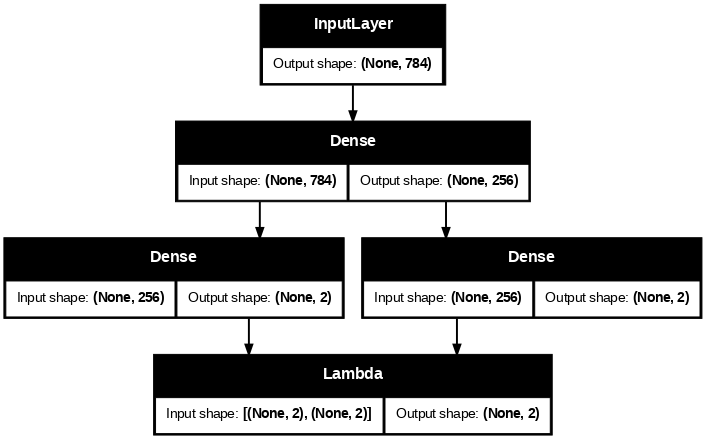

In [8]:
# ==========================================
# 3. 인코더 (Encoder) — Functional API
# ==========================================
encoder_inputs = layers.Input(shape=(input_dim,), name="encoder_input")
x = layers.Dense(intermediate_dim, activation="relu")(encoder_inputs)

# 잠재 공간의 평균(mean)과 로그 분산(log variance)을 출력하는 Dense 레이어
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

z = layers.Lambda(sampling, name="z")([z_mean, z_log_var])

encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()
keras.utils.plot_model(encoder, "encoder_info.png", show_shapes=True, dpi=70)

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ z_sampling (InputLayer)         │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 202,256 (790.06 KB)

 Trainable params: 202,256 (790.06 KB)

 Non-trainable params: 0 (0.00 B)

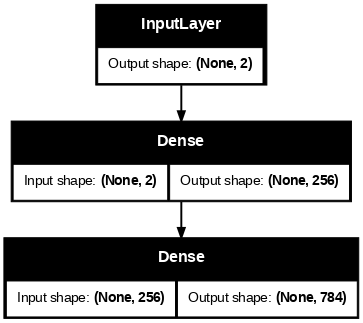

In [9]:
# ==========================================
# 4. 디코더 (Decoder) — Functional API
# ==========================================
latent_inputs = layers.Input(shape=(latent_dim,), name="z_sampling")
x = layers.Dense(intermediate_dim, activation="relu")(latent_inputs)
decoder_outputs = layers.Dense(input_dim, activation="sigmoid")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()
keras.utils.plot_model(decoder, "decoder_info.png", show_shapes=True, dpi=70)

In [10]:
# ==========================================
# 5. VAE — class 기반 (Keras 3 표준 방식)
# ==========================================
# encoder/decoder는 이미 완성된 부품이므로 함수형으로 만들었고,
# "두 부품을 결합하고 + KL loss를 더하는 로직"만 class로 감싼다.

class VAE(keras.Model):
    def __init__(self, encoder, decoder, kl_weight=0.001, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.kl_weight = kl_weight     # reconstruction loss 대비 kl_loss 에 대한 가중치

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)

        # KL divergence: 잠재분포 N(z_mean, exp(z_log_var))가
        # 표준정규분포 N(0, 1)에서 얼마나 벗어났는지 측정

        kl_loss = -0.5 * ops.sum(
            1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var), axis=1
        )
        self.add_loss(self.kl_weight * ops.mean(kl_loss))    # 에러 추가

        return reconstruction

vae = VAE(encoder, decoder, kl_weight=0.001, name="vae")
vae.build(input_shape=(None, input_dim))  # summary() 를 보기 위해 강제로 빌드 시킴.
vae.summary()

vae.compile(optimizer=keras.optimizers.Adam(), loss="binary_crossentropy")

Model: "vae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Functional)            │ ((None, 2), (None, 2), │       201,988 │
│                                 │ (None, 2))             │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 784)            │       202,256 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 404,244 (1.54 MB)

 Trainable params: 404,244 (1.54 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# ==========================================
# 6. MNIST 데이터 준비
# ==========================================
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train.reshape(-1, input_dim)
x_test = x_test.reshape(-1, input_dim)

In [37]:
x_train.shape, x_test.shape

((60000, 784), (10000, 784))

In [38]:
# ==========================================
# 7. 학습
# ==========================================
history = vae.fit(
    x_train, x_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, x_test),
)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.2450 - val_loss: 0.2386
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2256 - val_loss: 0.2186
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2159 - val_loss: 0.2139
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2125 - val_loss: 0.2108
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2097 - val_loss: 0.2091
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2081 - val_loss: 0.2077
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2068 - val_loss: 0.2064
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2057 - val_loss: 0.2051
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2045 - val_loss: 0.2043
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2035 - val_loss: 0.2032


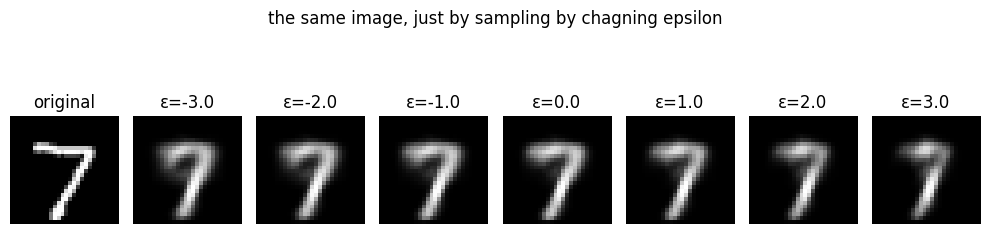

In [40]:
# ==========================================
# 8. epsilon을 바꿔가며 생성 결과 관찰
# ==========================================
sample_img = x_test[0:1] # x_test[0] 대신 x_test[0:1]을 사용하여 (1, 784) 형태로 전달
z_mean_sample, z_log_var_sample, _ = encoder.predict(sample_img, verbose=0)
std = np.exp(0.5 * z_log_var_sample)

epsilon_values = np.linspace(-3, 3, 7)
fig, axes = plt.subplots(1, len(epsilon_values) + 1, figsize=(10, 3))

axes[0].imshow(sample_img.reshape(28, 28), cmap="gray")
axes[0].set_title("original")
axes[0].axis("off")

for i, eps in enumerate(epsilon_values):
    epsilon_vec = np.array([[eps, eps]])
    z_sample = z_mean_sample + std * epsilon_vec
    reconstruction = decoder.predict(z_sample, verbose=0)

    axes[i + 1].imshow(reconstruction.reshape(28, 28), cmap="gray")
    axes[i + 1].set_title(f"ε={eps:.1f}")
    axes[i + 1].axis("off")

plt.suptitle("the same image, just by sampling by chagning epsilon")
plt.tight_layout()
plt.show()

In [45]:
print("z_mean:", z_mean_sample)
print("z_log_var:", z_log_var_sample)
print("std:", std)

z_mean: [[ 1.4911076  -0.18697254]]
z_log_var: [[-5.2421207 -4.8746634]]
std: [[0.0727257  0.08739374]]


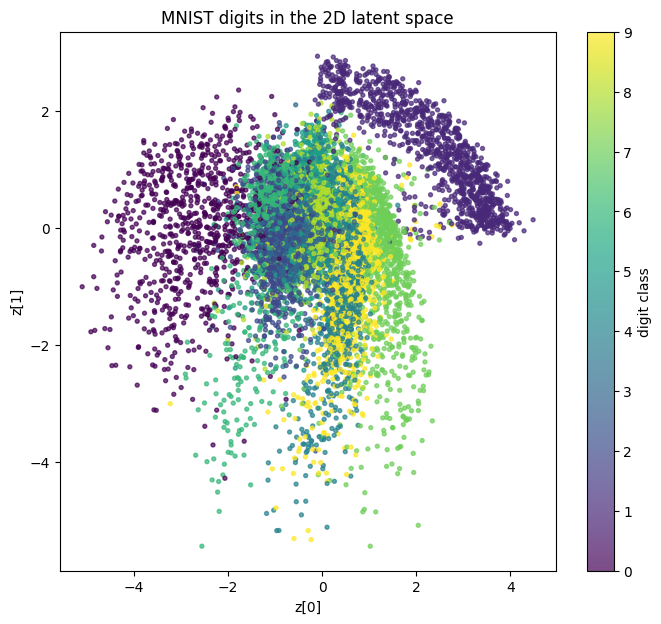

In [50]:
# ==========================================
# 9. 잠재공간(latent space)을 클래스별로 시각화
# ==========================================
# 레이블이 필요하므로 다시 불러온다 (x_train, x_test는 이미 있으므로 재사용)
(_, y_train), (_, y_test) = keras.datasets.mnist.load_data()

# 전체 test set을 encoder에 통과시켜 z_mean만 사용
# (분포의 "중심"만 보는 것이므로 z가 아니라 z_mean을 쓰는 게 표준)

z_mean_all, _, _ = encoder.predict(x_test, batch_size=128, verbose=0)

plt.figure(figsize=(8, 7))
scatter = plt.scatter(z_mean_all[:, 0], z_mean_all[:, 1], c=y_test, s=8, alpha=0.7)
plt.colorbar(scatter, ticks=range(10), label="digit class")
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.title("MNIST digits in the 2D latent space")
plt.show()

- Each of these colored clusters is a type of digit. Close clusters are digits that are structurally similar (i.e. digits that share information in the latent space).

- Because the VAE is a generative model, we can also use it to generate new digits! Here we will scan the latent plane, sampling latent points at regular intervals, and generating the corresponding digit for each of these points. This gives us a visualization of the latent manifold that "generates" the MNIST digits.

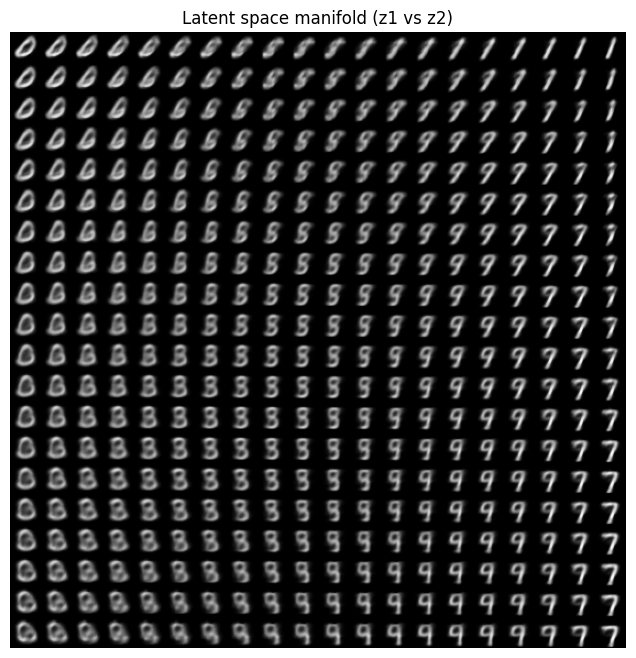

In [52]:
# ==========================================
# 10. 잠재공간(latent space)을 격자로 훑으며 생성 — Latent Manifold
# ==========================================
from scipy.stats import norm

n = 20            # 한 축에 몇 개의 점을 찍을지 (20 x 20 격자)
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))

# z_mean이 대략 표준정규분포를 따르도록 학습되므로, 균등한 간격(linspace)이 아니라
# "확률적으로 균등한 간격"을 위해 표준정규분포의 분위수(ppf)를 사용한다.
grid_x = norm.ppf(np.linspace(0.05, 0.95, n))
grid_y = norm.ppf(np.linspace(0.05, 0.95, n))[::-1]  # 위에서 아래로 갈수록 y가 감소하도록

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z_sample = np.array([[xi, yi]])
        digit = decoder.predict(z_sample, verbose=0)
        digit = digit.reshape(digit_size, digit_size)
        figure[
            i * digit_size : (i + 1) * digit_size,
            j * digit_size : (j + 1) * digit_size,
        ] = digit

plt.figure(figsize=(8, 8))
plt.imshow(figure, cmap="gray")
plt.title("Latent space manifold (z1 vs z2)")
plt.axis("off")
plt.show()

- You will get different distributions and different effect by giving various values of beta (the weight of kl_loss) in the loss.
- For more information, see
  - https://towardsdatascience.com/understanding-variational-autoencoders-vaes-f70510919f73 or
  - https://www.jeremyjordan.me/variational-autoencoders/

# Fashion MNIST

In [11]:
# ==========================================
# 6. MNIST 데이터 준비
# ==========================================
(x_train, _), (x_test, _) = keras.datasets.fashion_mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = x_train.reshape(-1, input_dim)
x_test = x_test.reshape(-1, input_dim)

In [12]:
history = vae.fit(
    x_train, x_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, x_test),
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 0.3921 - val_loss: 0.3605
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3555 - val_loss: 0.3538
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3501 - val_loss: 0.3504
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3463 - val_loss: 0.3465
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3441 - val_loss: 0.3450
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3426 - val_loss: 0.3432
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3413 - val_loss: 0.3425
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3402 - val_loss: 0.3412
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3393 - val_loss: 0.3408
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3385 - val_loss: 0.3396


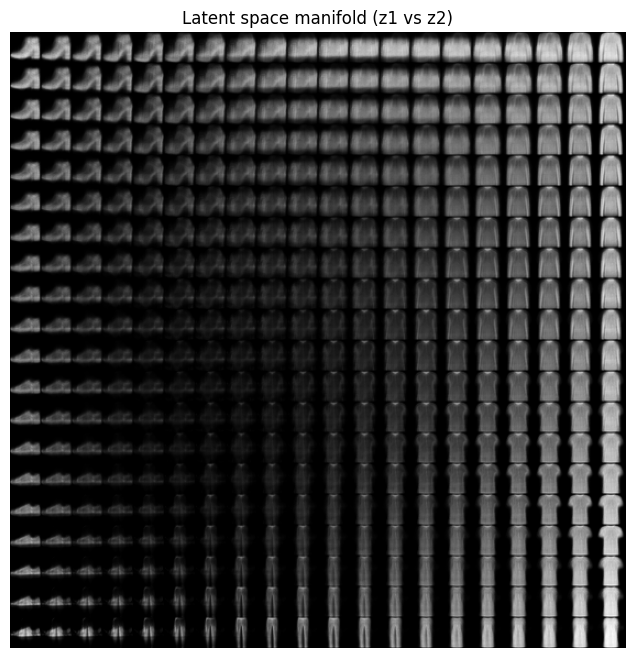

In [14]:
from scipy.stats import norm

n = 20            # 한 축에 몇 개의 점을 찍을지 (20 x 20 격자)
digit_size = 28
figure = np.zeros((digit_size * n, digit_size * n))

# z_mean이 대략 표준정규분포를 따르도록 학습되므로, 균등한 간격(linspace)이 아니라
# "확률적으로 균등한 간격"을 위해 표준정규분포의 분위수(ppf)를 사용한다.
grid_x = norm.ppf(np.linspace(0.05, 0.95, n))
grid_y = norm.ppf(np.linspace(0.05, 0.95, n))[::-1]  # 위에서 아래로 갈수록 y가 감소하도록

for i, yi in enumerate(grid_y):
    for j, xi in enumerate(grid_x):
        z_sample = np.array([[xi, yi]])
        digit = decoder.predict(z_sample, verbose=0)
        digit = digit.reshape(digit_size, digit_size)
        figure[
            i * digit_size : (i + 1) * digit_size,
            j * digit_size : (j + 1) * digit_size,
        ] = digit

plt.figure(figsize=(8, 8))
plt.imshow(figure, cmap="gray")
plt.title("Latent space manifold (z1 vs z2)")
plt.axis("off")
plt.show()

# Exercise

## Loss 처리 in keras

- 일반적인 메커니즘 — compile(loss=...)은 어떻게 동작하나
  - model.compile(loss=fn)으로 등록한 손실 함수는 시그니처가 정확히 fn(y_true, y_pred)이다. fit(x, y)를 부르면 내부적으로 매 배치마다:
    - y_pred = model(x) — 순전파로 최종 출력만 계산
    - loss = fn(y_true=y, y_pred=y_pred) — 모델의 "최종 출력"과, 우리가 준 "정답 y"만 가지고 손실 계산
    - 이 loss로 gradient 계산 → 가중치 업데이트
  - 즉, compile(loss=...)은 "모델 출력 vs 정답"이라는 지도학습(supervised) 형태만 표현할 수 있다. 여기엔 딱 두 가지 정보만 들어온다: 최종 출력 (y_pred), 그리고 외부에서 준 라벨 (y_true).
- vae 의 경우
  - 여기 쓰이는 z_mean, z_log_var는 모델의 최종 출력(reconstruction)도 아니고, 외부 정답(y)도 아니다. encoder 내부에서만 잠깐 존재하는 중간 텐서이다. compile(loss=fn)의 fn(y_true, y_pred)는 애초에 이 중간 텐서에 접근할 방법이 없다. (시그니처 자체가 "최종 출력 대 정답"만 받도록 고정돼 있음)
  - 따라서, "정답과 비교하는 손실이 아니라, 모델 내부 상태 자체에 거는 손실"이 필요할 때 쓰라고 있는 게 바로 add_loss()이다.
- add_loss를 포함한 전체 메커니즘: 매 배치 학습시,
  1. call()이 실행되면서 순전파가 진행됨
  2. 그 도중 self.add_loss(tensor)가 호출되면, 그 텐서가 모델의 self.losses라는 리스트에 쌓임 (y_true, y_pred와 무관하게, 그냥 그 순간 계산된 텐서 그대로)
  3. call()이 끝나고 최종 출력이 나오면, compile(loss=...)로 계산한 손실 + self.losses에 쌓인 모든 값 → 둘을 합쳐서 total loss로 만듦
  4. 이 total loss로 gradient 계산
  5. 다음 배치를 위해 self.losses는 초기화

## Keras 기반 Model 동작 메카니즘

- 클래스 계층 구조
  - keras.layers.Layer (가장 기본 단위: 가중치 + 순전파 계산)
  -    ->
  - keras.Model (Layer + 훈련 인프라: compile/fit/evaluate/save)
  - Layer가 "가중치를 갖고 입력을 출력으로 바꾸는 최소 단위"라면, Model은 거기에 compile(), fit(), evaluate(), save() 같은 학습용 기능을 추가로 얹은 것뿐이다. 그래서 Dense, Conv2D도 Layer, 우리가 만든 VAE도 (Model이니까) 결국 Layer이고, Layer 안에 Layer(또는 Model)를 넣는 것도 자유롭게 가능하다 — encoder, decoder가 Model이면서 동시에 VAE라는 더 큰 Model의 부품으로 들어갈 수 있는 이유임.

- keras.Model은 "가중치 생성(build)과 순전파(call)를 자동 관리해주는 Layer"에, "그 Layer를 어떻게 학습시킬지(compile/fit)"를 얹은 것 — 그래서 우리가 __init__에 부품을 등록하고 call()에 계산 순서만 적으면, 나머지(build 시점, 손실 수집, gradient, 가중치 업데이트)는 전부 부모 클래스가 대신 처리해준다.

- 새로운 Layer 나 Model 을 정의하려면 다음의 3 가지가 필수:
  - 상속: Layer 또는 Model (Layer + compile(), fit(), evaluate(), save())
  - super.\_\_init__() : "이 레이어가 어떤 부품(하위 레이어, 가중치)들을 갖고 있는지" 선언하는 곳
  - call() : 그 부품들을 어떤 순서로, 어떻게 조합해서 입력을 출력으로 바꿀지 계산 로직만 적는 곳

## norm.ppf()

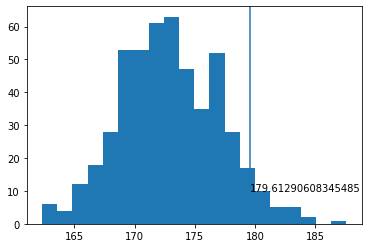

In [ ]:
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns

mean=172.7815
std=4.1532
N = 500

results=norm.rvs(mean, std, size=N)
pct_5 = norm.ppf(.95, mean, std)    # percent point function (inverse of cdf - percentiles)
plt.hist(results, bins=20)
plt.axvline(pct_5)
plt.annotate(pct_5, xy=(pct_5, 10))
plt.show()

In [ ]:
n = 15
grid_x = norm.ppf(np.linspace(0.05, 0.95, n))
grid_y = norm.ppf(np.linspace(0.05, 0.95, n))

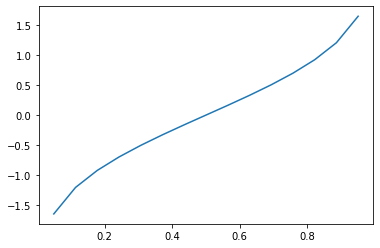

In [ ]:
grid_x = norm.ppf(np.linspace(0.05, 0.95, n))
plt.plot(np.linspace(0.05, 0.95, n), grid_x)

In [ ]:
rv = norm(loc = 0, scale = 1) # 표준정규확률객체 만들기
rv.ppf(0.5), rv.ppf(0.6)      # 0.5, 0.6 분위수값 (cumulative prob. function 에서)

(0.0, 0.2533471031357997)

In [ ]:
norm.ppf(0.6, 0, 1)    # 분위수(quartile) 0.6, mean =0, sigma = 1 normal

0.2533471031357997

In [ ]:
norm.ppf (0.05), norm.ppf(0.5), norm.ppf (0.95)

(-1.6448536269514729, 0.0, 1.6448536269514722)

In [ ]:
norm.ppf (np.linspace(0.05, 0.95, 10))

array([-1.64485363, -1.03643339, -0.67448975, -0.38532047, -0.12566135,
        0.12566135,  0.38532047,  0.67448975,  1.03643339,  1.64485363])

## KL diveregence (or Relative Entropy)
  - The relative entropy from Q to P is often denoted D_KL(P||Q).
  - KL(P||Q) = H(P,Q) - H(P)
  - In the context of machine learning, D_KL(P||Q) is often called the information gain achieved if P would be used instead of Q which is currently used.
  - Relative entropy D_KL(P||Q) can be thought of as something like a measurement of how far the distribution Q is from the distribution P.
  - The cross-entropy H(P,Q) is itself such a measurement, but it has the defect that H(P,P)=:H(P) isn't zero, so we subtract H(P) to make D_KL(P||Q) agree more closely with our notion of distance. (Unfortunately it still isn't symmetric.)

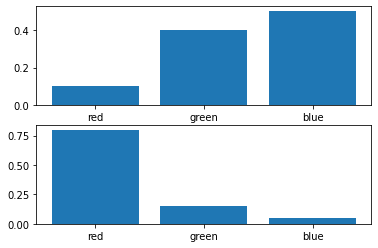

In [ ]:
from matplotlib import pyplot
# define distributions
events = ['red', 'green', 'blue']
p = [0.10, 0.40, 0.50]
q = [0.80, 0.15, 0.05]

pyplot.subplot(2,1,1)
pyplot.bar(events, p)
pyplot.subplot(2,1,2)
pyplot.bar(events, q)
pyplot.show()

In [ ]:
# calculate the kl divergence : KL(P||Q) = H(P,Q) - H(P)
def kl_divergence(p, q):
    p, q = np.array(p), np.array(q)
    kl_div = p * np.log(p/q)
    return np.sum(kl_div)

In [ ]:
# calculate (P || Q)
kl_pq = kl_divergence(p, q)
print('KL(P || Q): %.3f bits' % kl_pq)
# calculate (Q || P)
kl_qp = kl_divergence(q, p)
print('KL(Q || P): %.3f bits' % kl_qp)

KL(P || Q): 1.336 bits
KL(Q || P): 1.401 bits


In [ ]:
# example of calculating the kl divergence (relative entropy) with scipy
from scipy.special import rel_entr
# define distributions
p = [0.10, 0.40, 0.50]
q = [0.80, 0.15, 0.05]
# calculate (P || Q)
kl_pq = rel_entr(p, q)
print('KL(P || Q): %.3f nats' % sum(kl_pq))
# calculate (Q || P)
kl_qp = rel_entr(q, p)
print('KL(Q || P): %.3f nats' % sum(kl_qp))

KL(P || Q): 1.336 nats
KL(Q || P): 1.401 nats
